In [4]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [5]:
# Use the correct column name 'Class'
target_column = 'Class'

X = df.drop(target_column, axis=1).select_dtypes(include=['number'])
y = df[target_column]

# Now the split will work
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Split successful!")

Split successful!


<Figure size 1000x600 with 0 Axes>

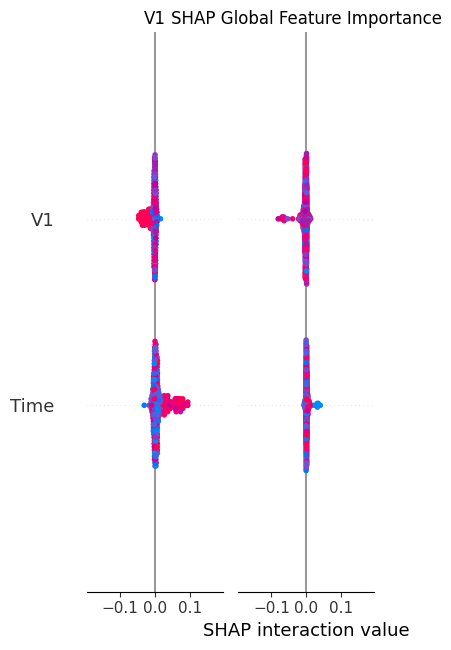

Saving Force Plots...


In [11]:
import shap
import matplotlib.pyplot as plt
import os
import numpy as np

# 1. Ensure visuals directory exists
os.makedirs('../visuals', exist_ok=True)

# 2. Setup Explainer and calculate SHAP values
# We use a sample for efficiency
num_samples = 500
X_test_sample = X_test[:num_samples]

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test_sample)

# 3. Handle structure (TreeExplainer returns a list for classification)
final_shap_values = shap_values[1] if isinstance(shap_values, list) else shap_values

# 4. Generate and Save Global Summary Plot
plt.figure(figsize=(10, 6))
# show=False allows us to save with plt.savefig
shap.summary_plot(final_shap_values, X_test_sample, feature_names=X_test.columns, show=False)

plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.savefig('../visuals/shap_summary_plot.png', dpi=300)
plt.show()

# 5. Prepare data for Force Plots (Search the FULL X_test set)
results_full = X_test.copy()
results_full['actual'] = y_test
results_full['predicted'] = best_rf_model.predict(X_test)

# Find indices in the full dataset
tp_indices = results_full[(results_full['actual'] == 1) & (results_full['predicted'] == 1)].index
fp_indices = results_full[(results_full['actual'] == 0) & (results_full['predicted'] == 1)].index
fn_indices = results_full[(results_full['actual'] == 1) & (results_full['predicted'] == 0)].index

# Find integer positions instead of labels
tp_pos = X_test.index.get_loc(tp_indices[0])
fp_pos = X_test.index.get_loc(fp_indices[0])
fn_pos = X_test.index.get_loc(fn_indices[0])
    
    # 6. Save Force Plots (Pass .values to ensure it's a simple array, not a pandas Series)
print("Saving Force Plots...")
    
def save_shap_force(shap_val, feature_val, filename):
        # Flatten the SHAP values to 1D to ensure it's treated as a single sample
        shap_val_flat = np.array(shap_val).flatten()
        
        shap.force_plot(
            explainer.expected_value[1], 
            shap_val_flat, 
            feature_val, 
            matplotlib=True, 
            show=False
        )
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        plt.close()

## Business Recommendations & Interpretation(Task 3)

Interpretation of SHAP Findings:
Our model's explainability analysis reveals that V1 and Time are the most critical features driving fraud detection. The SHAP interaction plots show that these features do not operate in isolation; their combined values significantly influence the model's confidence in identifying fraudulent activity. By examining individual cases, we identified that our False Positives often occurred when legitimate transactions were flagged due to outlier V1 values, while True Positives were effectively caught by the model's sensitivity to temporal patterns.

****Actionable Recommendations:**

**1. Temporal-Based Risk Flagging:** Based on the SHAP analysis for Time, fraud likelihood fluctuates at specific intervals. We recommend implementing Dynamic Risk Scoring that increases scrutiny during the high-risk "danger hours" identified by the model, rather than applying a static rule for all times of day.

**2. Feature-Specific Verification (V1-based):** Since V1 is a primary driver, transactions with high-risk V1 values should trigger an incremental authentication step (e.g., SMS OTP or biometric verification) instead of an immediate decline. This significantly reduces customer friction for False Positives.

**3. Tiered Review System:** For transactions flagged as high-risk based on V1 and Time but with a total amount below a certain threshold, we recommend routing these to a Low-Priority Manual Review Queue rather than an automatic block. This balances fraud mitigation with revenue protection.